In [1]:
import pandas as pd
import numpy as np

df_tv = pd.read_csv('data/train.csv')

df_tv.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [2]:
# import matplotlib.pyplot as plt
# from mlxtend.plotting import scatterplotmatrix
# scatterplotmatrix(df_tv.values, figsize=(12, 10), names=df_tv.columns, alpha=0.5)
# plt.tight_layout()
# plt.show()

In [ ]:
# df_t = df_tv

# #identify all categorical variables
# cat_columns = df_t.select_dtypes(['object']).columns

# #convert all categorical variables to numeric
# df_t[cat_columns] = df_t[cat_columns].apply(lambda x: pd.factorize(x)[0])
# df_t.head()

In [3]:
df_tv.isnull().sum()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

<Axes: xlabel='Irrigation_Need'>

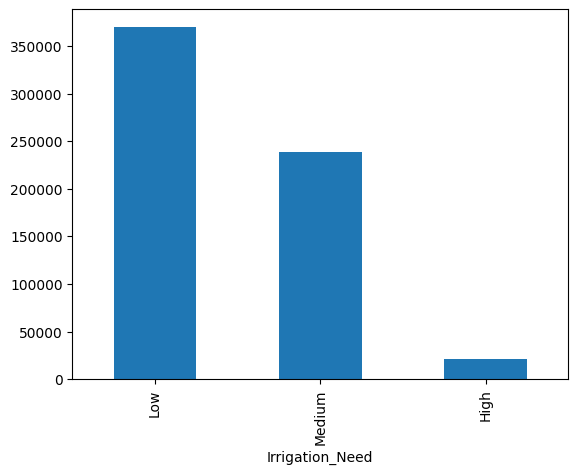

In [4]:
counts = df_tv['Irrigation_Need'].value_counts()
counts.plot(kind='bar')

<Axes: xlabel='Irrigation_Need'>

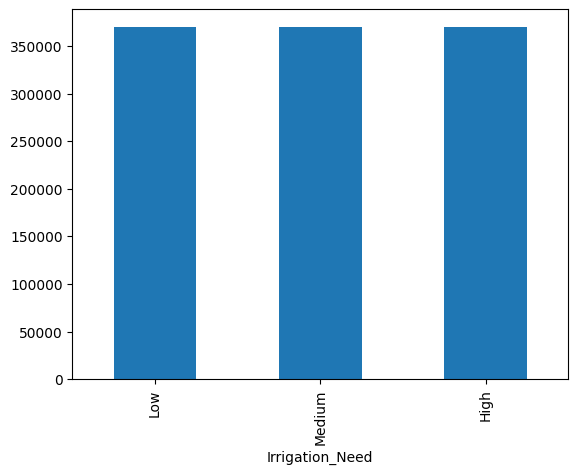

In [5]:
from sklearn.utils import resample

df_tv_majority = df_tv[df_tv['Irrigation_Need'] == counts.keys()[0]]
df_tv_mid = df_tv[df_tv['Irrigation_Need'] == counts.keys()[1]]
df_tv_minority = df_tv[df_tv['Irrigation_Need'] == counts.keys()[2]]
# Oversample minority class
minority_upsampled = resample(df_tv_minority, 
                              replace=True,  # Sample with replacement
                              n_samples=len(df_tv_majority),  # Equalize class sizes
                              random_state=42)
# Oversample mid class
mid_upsampled = resample(df_tv_mid, 
                         replace=True,  # Sample with replacement
                         n_samples=len(df_tv_majority),  # Equalize class sizes
                         random_state=42)
df_balanced = pd.concat([df_tv_majority, mid_upsampled, minority_upsampled])

counts = df_balanced['Irrigation_Need'].value_counts()
counts.plot(kind='bar')

In [6]:
continous_variables = df_tv.select_dtypes(['float64']).columns
continous_variables

Index(['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
       'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
       'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm'],
      dtype='object')

In [ ]:
#balanced data set

from sklearn.preprocessing import LabelEncoder
class_le = LabelEncoder()
y = class_le.fit_transform(df_balanced['Irrigation_Need'].values)

df_dummy = pd.get_dummies(df_balanced.iloc[:,1:-1], dtype=int)

from sklearn.preprocessing import StandardScaler

sc = StandardScaler().fit(df_dummy[continous_variables])
df_dummy[continous_variables] = sc.transform(df_dummy[continous_variables])
x = df_dummy.to_numpy()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = \
    train_test_split(x, y, 
                     test_size=0.20,
                     stratify=y,
                     random_state=1)

from sklearn.tree import DecisionTreeClassifier

# dt = DecisionTreeClassifier()
# dt.fit(X_train, y_train)
# dt.score(X_test, y_test)

df_test = pd.read_csv('data/test.csv')

ids = df_test['id'].values


df_test_dummy = pd.get_dummies(df_test.iloc[:,1:])
df_test_dummy[continous_variables] = sc.transform(df_test_dummy[continous_variables])
x_test = df_test_dummy.to_numpy()

# dt_submission = pd.DataFrame({'id': ids, 'Irrigation_Need': class_le.inverse_transform(dt.predict(x_test))})
# dt_submission.to_csv('data/submission-dt_balanced_v1.csv', index=False)

import xgboost as xgb
from sklearn.model_selection import GridSearchCV
mxgb_gs = GridSearchCV(xgb.XGBClassifier(random_state=1, n_jobs=-1, tree_method='hist', device='cuda'), 
                         param_grid={'n_estimators': [100, 500, 1000], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 4, 5]}, 
                         cv=5, scoring='balanced_accuracy', n_jobs=-1)
mxgb_gs.fit(X_train, y_train)
mxgb_gs.score(X_test, y_test)

df_submission_mxgb_gs = pd.DataFrame({'id': ids, 'Irrigation_Need': class_le.inverse_transform(mxgb_gs.predict(x_test))})
df_submission_mxgb_gs.to_csv('data/submission-mxgb_gs__balancedv1.csv', index=False)

In [4]:
from sklearn.preprocessing import LabelEncoder
class_le = LabelEncoder()
y = class_le.fit_transform(df_tv['Irrigation_Need'].values)

In [5]:
df_dummy = pd.get_dummies(df_tv.iloc[:,1:-1], dtype=int)

In [6]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler().fit(df_dummy[continous_variables])
df_dummy[continous_variables] = sc.transform(df_dummy[continous_variables])
x = df_dummy.to_numpy()

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = \
    train_test_split(x, y, 
                     test_size=0.20,
                     stratify=y,
                     random_state=1)

In [9]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=.10, solver='lbfgs', class_weight="balanced")
lr.fit(X_train, y_train)



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [10]:

test_acc = lr.score(X_test, y_test)
print(f'Test accuracy: {test_acc:.3f}')

Test accuracy: 0.843


In [11]:
# from sklearn.model_selection import cross_val_score
# scores = cross_val_score(estimator=lr,
#                          X=x,
#                          y=y,
#                          cv=10,
#                          n_jobs=1)
# print(f'CV accuracy scores: {scores}')
# print(f'CV accuracy: {np.mean(scores):.3f} '
#       f'+/- {np.std(scores):.3f}')



In [12]:
import scipy.stats

param_range = [0.0001, 0.001, 0.01, 0.1,
               1.0, 10.0, 100.0, 1000.0]

param_range = scipy.stats.loguniform(0.0001, 1000.0)

np.random.seed(1)
param_range.rvs(10)

param_grid = [{'C': param_range}]
param_range

In [13]:
from sklearn.model_selection import RandomizedSearchCV
rs = RandomizedSearchCV(estimator=lr,
                        param_distributions=param_grid,
                        scoring='accuracy',
                        refit=True,
                        n_iter=10,
                        cv=5,
                        random_state=1,
                        n_jobs=-1)

In [14]:
rs = rs.fit(x, y)
print(rs.best_score_)

0.8424666666666667


In [45]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt.score(X_test, y_test)

0.9700634920634921

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

gs = GridSearchCV(estimator=DecisionTreeClassifier(random_state=0),
                  param_grid=[{'max_depth': [1, 2, 3, 4, 5, 6, 7, None]}],
                  scoring='balanced_accuracy',
                  cv=2)

gs.fit(x, y)
print(gs.best_score_)
# scores = cross_val_score(gs, x, y, 
#                          scoring='accuracy', cv=5)
# print(f'CV accuracy: {np.mean(scores):.3f} '
#       f'+/- {np.std(scores):.3f}')

0.9619432310111605


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
gsf = GridSearchCV(estimator=RandomForestClassifier(n_estimators=100, random_state=1, n_jobs=-1, class_weight="balanced"),
                  param_grid=[{'max_depth': [1, 2, 3, 4, 5, 6, 7, None]}],
                  scoring='balanced_accuracy',
                  cv=2)

gsf.fit(x,y)
print(gsf.best_score_)

0.9577293625914842


In [11]:
df_test = pd.read_csv('data/test.csv')

ids = df_test['id'].values


df_test_dummy = pd.get_dummies(df_test.iloc[:,1:])
df_test_dummy[continous_variables] = sc.transform(df_test_dummy[continous_variables])
x_test = df_test_dummy.to_numpy()

#df_submission = pd.DataFrame({'id': ids, 'Irrigation_Need': class_le.inverse_transform(gsf.predict(x_test))})
#df_submission.to_csv('data/submission-rf_v1.csv', index=False)
#df_submission_lr = pd.DataFrame({'id': ids, 'Irrigation_Need': class_le.inverse_transform(lr.predict(x_test))})
#df_submission_lr.to_csv('data/submission-lr_v1.csv', index=False)
df_submission_gs = pd.DataFrame({'id': ids, 'Irrigation_Need': class_le.inverse_transform(gs.predict(x_test))})
df_submission_gs.to_csv('data/submission-gs_v1.csv', index=False)

In [24]:
import xgboost as xgb
mxgb = xgb.XGBClassifier(n_estimators=1000, learning_rate=0.01, max_depth=4, 
                          random_state=1, n_jobs=-1, tree_method='hist')
mxgb.fit(X_train, y_train)
mxgb.score(X_test, y_test)

0.9840634920634921

In [23]:
df_submission_mxgb = pd.DataFrame({'id': ids, 'Irrigation_Need': class_le.inverse_transform(mxgb.predict(x_test))})
df_submission_mxgb.to_csv('data/submission-mxgb_v1.csv', index=False)

In [16]:
from sklearn.decomposition import PCA
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [18]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
mxgb_gs = GridSearchCV(xgb.XGBClassifier(random_state=1, n_jobs=-1, tree_method='hist'), 
                         param_grid={'n_estimators': [100, 500, 1000], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 4, 5]}, 
                         cv=5, scoring='balanced_accuracy')
mxgb_gs.fit(X_train, y_train)
mxgb_gs.score(X_test, y_test)

0.9632661281592013

In [19]:
df_submission_mxgb_gs = pd.DataFrame({'id': ids, 'Irrigation_Need': class_le.inverse_transform(mxgb_gs.predict(x_test))})
df_submission_mxgb_gs.to_csv('data/submission-mxgb_gs_v1.csv', index=False)

In [ ]:
from sklearn.svm import SVC
svm = SVC(kernel='linear', C=1.0, random_state=1)
svm.fit(X_train_pca, y_train)
svm.score(X_test_pca, y_test)

In [22]:
# from sklearn.ensemble import VotingClassifier

# voting_clf = VotingClassifier(estimators=[('rf', gsf), ('lr', lr)], voting='soft')
# voting_clf.fit(x, y)

